# Predicción de supervivencia del Titanic con Machine Learning

## Unidad 05

### Machine Learning con Scikit-learn

Dataset: Titanic - Machine Learning from Disaster  
Fuente: Kaggle  
Modelo: Random Forest Classifier

**Estudiante:** Al Farias Leyva  
**Matrícula:** 230389  
**Grupo:** 9A IDGS  
**Institución:** Universidad Tecnológica de Xicotepec de Juárez

## 1. Objetivo

El propósito es construir un modelo de aprendizaje supervisado que clasifique a los pasajeros en dos grupos: sobrevivió o no sobrevivió. Se utilizará el conjunto de entrenamiento oficial de Kaggle y un pipeline de Scikit-learn para mantener unidos el preprocesamiento y el modelo.

## 2. Importaciones

Pandas se utiliza para manipular los datos. Las herramientas de Scikit-learn permiten dividir el dataset, transformar columnas, entrenar el Random Forest y evaluar sus predicciones.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

Matplotlib is building the font cache; this may take a moment.


## 3. Carga y validación del dataset

El notebook busca el archivo tanto desde la raíz del repositorio como desde la carpeta del notebook. Si no existe, se detiene con instrucciones claras: no genera ni reemplaza datos. También verifica que estén presentes las columnas requeridas.

In [2]:
candidate_paths = [
    Path("Practica10/data/train.csv"),
    Path("../data/train.csv"),
]

data_path = next(
    (path for path in candidate_paths if path.exists()),
    candidate_paths[0],
)

if not data_path.exists():
    raise FileNotFoundError(
        "No se encontró el dataset oficial. Descarga train.csv desde "
        "https://www.kaggle.com/competitions/titanic/data y colócalo en "
        "Practica10/data/train.csv."
    )

df = pd.read_csv(data_path)

required_columns = {
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked",
    "Survived",
}
missing_columns = required_columns.difference(df.columns)

if missing_columns:
    raise ValueError(
        "El CSV no contiene las columnas requeridas: "
        + ", ".join(sorted(missing_columns))
    )

print(f"Dataset cargado desde: {data_path.resolve()}")
print(f"Registros cargados: {len(df)}")

Dataset cargado desde: /Users/farias/UTXJ/ECBD_9A_IDGS_230389/ECBD_9AIDGS_PRACTICAS_230389/Practica10/data/train.csv
Registros cargados: 891


## 4. Exploración de datos

Antes de entrenar se revisan ejemplos, dimensiones, tipos de datos, valores faltantes y balance de clases. Esta inspección ayuda a decidir qué transformaciones necesita cada variable.

In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Las primeras filas permiten comprobar visualmente que cada registro corresponde a un pasajero y que las columnas esperadas fueron leídas correctamente.

In [4]:
df.shape

(891, 12)

La tupla anterior muestra, en ese orden, la cantidad de filas y columnas disponibles en el archivo.

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


El resumen permite distinguir columnas numéricas y categóricas, además de comparar la cantidad de valores no nulos. Las diferencias entre el total de filas y los valores no nulos señalan datos faltantes.

In [6]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Este conteo identifica exactamente qué variables tienen valores faltantes. El pipeline los tratará sin eliminar pasajeros: mediana para variables numéricas y categoría más frecuente para variables categóricas.

In [7]:
survival_counts = df["Survived"].value_counts().sort_index()
survival_percentages = (
    df["Survived"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

pd.DataFrame({
    "Cantidad": survival_counts,
    "Porcentaje": survival_percentages,
}).rename(index={0: "No sobrevivió", 1: "Sobrevivió"})

,Cantidad,Porcentaje
Survived,,
No sobrevivió,549,61.62
Sobrevivió,342,38.38


La tabla muestra la cantidad y proporción de cada clase. Esta revisión justifica usar una división estratificada, de forma que entrenamiento y prueba conserven aproximadamente la misma distribución.

In [8]:
df.groupby("Sex")["Survived"].agg(
    Pasajeros="count",
    Tasa_supervivencia="mean",
).assign(
    Tasa_supervivencia_porcentaje=lambda table: (
        table["Tasa_supervivencia"] * 100
    ).round(2)
)

,Pasajeros,Tasa_supervivencia,Tasa_supervivencia_porcentaje
Sex,,,
female,314,0.742038,74.20
male,577,0.188908,18.89


La tasa es la media de una variable codificada con 0 y 1, por lo que también representa la proporción de supervivencia de cada categoría de sexo. La salida permite comparar los grupos sin confundir cantidad de pasajeros con porcentaje.

In [9]:
df.groupby("Pclass")["Survived"].agg(
    Pasajeros="count",
    Tasa_supervivencia="mean",
).assign(
    Tasa_supervivencia_porcentaje=lambda table: (
        table["Tasa_supervivencia"] * 100
    ).round(2)
)

,Pasajeros,Tasa_supervivencia,Tasa_supervivencia_porcentaje
Pclass,,,
1,216,0.629630,62.96
2,184,0.472826,47.28
3,491,0.242363,24.24


La tabla compara la supervivencia entre primera, segunda y tercera clase. Esta diferencia exploratoria muestra por qué Pclass puede aportar información al clasificador, aunque por sí sola no determina el resultado de una persona.

### Visualizaciones de supervivencia

Las siguientes gráficas resumen la distribución de la variable objetivo y las tasas de supervivencia según sexo y clase. Facilitan comparar visualmente los grupos sin reemplazar el análisis numérico anterior.

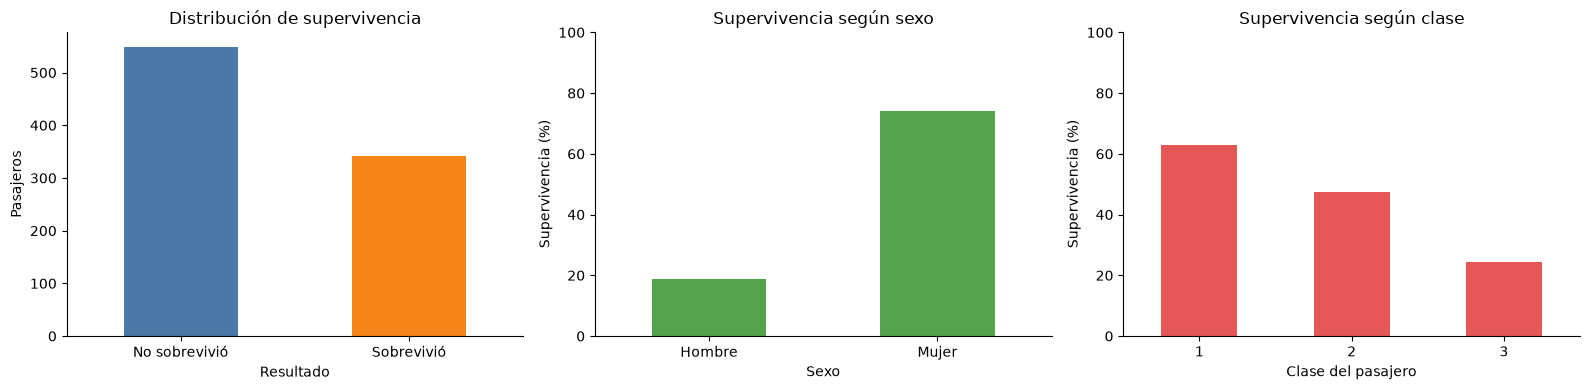

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

survival_labels = df["Survived"].map({
    0: "No sobrevivió",
    1: "Sobrevivió",
})
survival_labels.value_counts().reindex([
    "No sobrevivió",
    "Sobrevivió",
]).plot(
    kind="bar",
    color=["#4C78A8", "#F58518"],
    ax=axes[0],
)
axes[0].set_title("Distribución de supervivencia")
axes[0].set_xlabel("Resultado")
axes[0].set_ylabel("Pasajeros")

survival_by_sex = (
    df.assign(Sexo=df["Sex"].map({"male": "Hombre", "female": "Mujer"}))
    .groupby("Sexo")["Survived"]
    .mean()
    .mul(100)
)
survival_by_sex.plot(kind="bar", color="#54A24B", ax=axes[1])
axes[1].set_title("Supervivencia según sexo")
axes[1].set_xlabel("Sexo")
axes[1].set_ylabel("Supervivencia (%)")
axes[1].set_ylim(0, 100)

survival_by_class = df.groupby("Pclass")["Survived"].mean().mul(100)
survival_by_class.plot(kind="bar", color="#E45756", ax=axes[2])
axes[2].set_title("Supervivencia según clase")
axes[2].set_xlabel("Clase del pasajero")
axes[2].set_ylabel("Supervivencia (%)")
axes[2].set_ylim(0, 100)

for ax in axes:
    ax.tick_params(axis="x", rotation=0)
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

## 5. Variables del modelo

Se usan siete características disponibles antes de conocer el resultado. Survived es la variable objetivo: 0 significa que no sobrevivió y 1 que sobrevivió.

In [11]:
features = [
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked",
]
target = "Survived"

X = df[features]
y = df[target]

print("Características:", features)
print("Variable objetivo:", target)
print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)

Características: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
Variable objetivo: Survived
Dimensiones de X: (891, 7)
Dimensiones de y: (891,)


## 6. División de entrenamiento y prueba

El 80 % de los registros se utiliza para que el modelo aprenda y el 20 % restante para medir su desempeño con ejemplos que no vio durante el entrenamiento. stratify conserva la proporción de las dos clases y random_state hace reproducible la división.

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print(f"Registros de entrenamiento: {len(X_train)}")
print(f"Registros de prueba: {len(X_test)}")
print(
    "Proporción de supervivencia en entrenamiento: "
    f"{y_train.mean():.2%}"
)
print(
    "Proporción de supervivencia en prueba: "
    f"{y_test.mean():.2%}"
)

Registros de entrenamiento: 712
Registros de prueba: 179
Proporción de supervivencia en entrenamiento: 38.34%
Proporción de supervivencia en prueba: 38.55%


## 7. Preprocesamiento

Las variables numéricas reciben una imputación por mediana. En las categóricas se completa el valor más frecuente y luego se crean columnas binarias con OneHotEncoder. handle_unknown="ignore" permite predecir aunque aparezca una categoría no vista durante el entrenamiento.

In [13]:
numeric_features = [
    "Pclass",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
]
categorical_features = [
    "Sex",
    "Embarked",
]

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_transformer, numeric_features),
    ("categorical", categorical_transformer, categorical_features),
])

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``fe

## 8. Modelo y pipeline

RandomForestClassifier combina numerosos árboles de decisión. Se emplean 200 árboles y una semilla fija para obtener un resultado reproducible. El pipeline garantiza que el mismo preprocesamiento se aplique durante el entrenamiento, la evaluación y las pruebas manuales.

In [14]:
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
)

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", model),
])

pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, 

## 9. Entrenamiento

fit calcula las imputaciones y categorías únicamente con el conjunto de entrenamiento; después transforma esos datos y ajusta los 200 árboles del clasificador.

In [15]:
pipeline.fit(X_train, y_train)

print("Entrenamiento completado correctamente.")

Entrenamiento completado correctamente.


## 10. Predicciones

El modelo procesa el conjunto de prueba y produce una clase para cada pasajero. La siguiente tabla compara diez valores reales con su predicción.

In [16]:
y_pred = pipeline.predict(X_test)

comparison = pd.DataFrame({
    "Real": y_test.iloc[:10].map({
        0: "No sobrevivió",
        1: "Sobrevivió",
    }).to_numpy(),
    "Predicción": pd.Series(y_pred[:10]).map({
        0: "No sobrevivió",
        1: "Sobrevivió",
    }),
})

comparison

,Real,Predicción
0,No sobrevivió,No sobrevivió
1,No sobrevivió,No sobrevivió
2,Sobrevivió,No sobrevivió
3,No sobrevivió,No sobrevivió
4,Sobrevivió,Sobrevivió
5,Sobrevivió,No sobrevivió
6,Sobrevivió,Sobrevivió
7,No sobrevivió,Sobrevivió
8,No sobrevivió,No sobrevivió
9,No sobrevivió,No sobrevivió


## 11. Evaluación

### Accuracy

Accuracy es la proporción total de predicciones correctas. Se presenta como decimal y como porcentaje con dos decimales.

In [17]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Accuracy: {accuracy:.2%}")

Accuracy: 0.8212
Accuracy: 82.12%


### Matriz de confusión

Las filas representan los valores reales y las columnas las predicciones. La diagonal contiene los aciertos; las otras celdas muestran los dos tipos de error.

In [18]:
confusion = confusion_matrix(y_test, y_pred)

confusion_df = pd.DataFrame(
    confusion,
    index=[
        "Real: No sobrevivió",
        "Real: Sobrevivió",
    ],
    columns=[
        "Predicción: No sobrevivió",
        "Predicción: Sobrevivió",
    ],
)

confusion_df

,Predicción: No sobrevivió,Predicción: Sobrevivió
Real: No sobrevivió,99,11
Real: Sobrevivió,21,48


La versión gráfica usa colores más intensos para los conteos mayores y conserva los valores exactos dentro de cada celda.

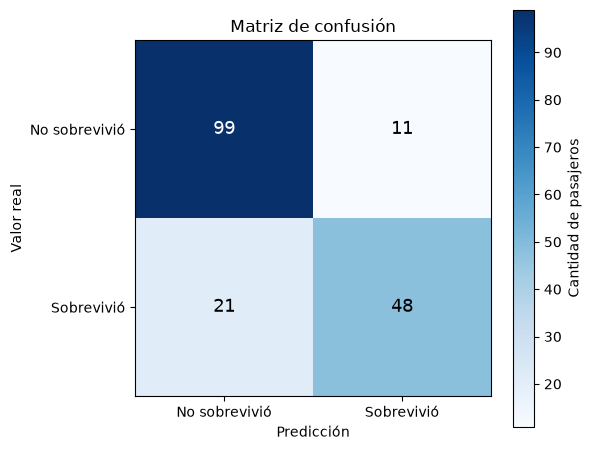

In [19]:
fig, ax = plt.subplots(figsize=(6, 5))
image = ax.imshow(confusion, cmap="Blues")

for row in range(confusion.shape[0]):
    for column in range(confusion.shape[1]):
        ax.text(
            column,
            row,
            confusion[row, column],
            ha="center",
            va="center",
            color="white" if confusion[row, column] > confusion.max() / 2 else "black",
            fontsize=13,
        )

ax.set_xticks([0, 1], labels=["No sobrevivió", "Sobrevivió"])
ax.set_yticks([0, 1], labels=["No sobrevivió", "Sobrevivió"])
ax.set_xlabel("Predicción")
ax.set_ylabel("Valor real")
ax.set_title("Matriz de confusión")
fig.colorbar(image, ax=ax, label="Cantidad de pasajeros")
plt.tight_layout()
plt.show()

### Classification report

Precision indica qué proporción de las predicciones de una clase fue correcta. Recall indica qué proporción de los casos reales de esa clase fue encontrada. F1-score equilibra precision y recall. Accuracy resume el porcentaje correcto considerando ambas clases.

In [20]:
report = classification_report(
    y_test,
    y_pred,
    target_names=[
        "No sobrevivió",
        "Sobrevivió",
    ],
    digits=4,
)

print(report)

               precision    recall  f1-score   support

No sobrevivió     0.8250    0.9000    0.8609       110
   Sobrevivió     0.8136    0.6957    0.7500        69

     accuracy                         0.8212       179
    macro avg     0.8193    0.7978    0.8054       179
 weighted avg     0.8206    0.8212    0.8181       179



## 12. Prueba con pasajeros nuevos

Se crean dos perfiles ficticios con características diferentes. No es necesario transformar sus columnas manualmente porque el pipeline aplica todas las operaciones antes de predecir.

In [21]:
new_passengers = pd.DataFrame([
    {
        "Pclass": 3,
        "Sex": "male",
        "Age": 22,
        "SibSp": 1,
        "Parch": 0,
        "Fare": 7.25,
        "Embarked": "S",
    },
    {
        "Pclass": 1,
        "Sex": "female",
        "Age": 38,
        "SibSp": 1,
        "Parch": 0,
        "Fare": 71.28,
        "Embarked": "C",
    },
])

manual_predictions = pipeline.predict(new_passengers)
prediction_labels = {
    0: "No sobrevivió",
    1: "Sobrevivió",
}

manual_results = new_passengers.copy()
manual_results.insert(
    0,
    "Pasajero",
    range(1, len(manual_results) + 1),
)
manual_results["Predicción"] = [
    prediction_labels[value] for value in manual_predictions
]

manual_results

,Pasajero,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Predicción
0,1,3,male,22,1,0,7.25,S,No sobrevivió
1,2,1,female,38,1,0,71.28,C,Sobrevivió


Estas respuestas son predicciones estadísticas construidas a partir de patrones del conjunto de entrenamiento. No representan una certeza histórica ni deben interpretarse como una regla sobre personas reales.

## 13. Conclusión

Este ejercicio permite seguir un proceso completo de clasificación supervisada: revisar datos, separar variables, evitar fugas de información, preprocesar valores faltantes y categorías, entrenar un modelo y evaluarlo con varias métricas. El pipeline mantiene el trabajo reproducible y facilita aplicar el modelo a nuevos registros. Al interpretar el resultado es importante considerar tanto los aciertos como los errores y recordar que el modelo aprende asociaciones presentes en un dataset histórico.